🚀 [步驟二] Stacking 混合訓練 (七大模型合體)...
✅ 資料載入成功: 47275 筆
🔄 TF-IDF 轉換 (Max 5000, float32)...
✂️ 10-Fold 切分...
⚖️ 執行 SMOTE 過取樣...
   -> 訓練集擴增至: 146304 筆
WZ️ 定義模型組合...
🏋️ 開始訓練 Stacking 模型 (這會花一點時間，請稍候)...
   ⚠️ 訓練資料量大，為防崩潰，暫時移除 KNN...


Exception ignored in: <function ResourceTracker.__del__ at 0x103e2a020>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x11569a020>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x11127e020>
Traceback (most recent call last

✅ 訓練完成！耗時: 727.1 秒
📊 評估結果...

🏆 Stacking Accuracy: 0.7134

Classification Report:
                  precision    recall  f1-score   support

      feel_angry       0.67      0.67      0.67       635
     feel_boring       0.67      0.76      0.71       285
 feel_depressing       0.80      0.81      0.80       320
      feel_happy       0.66      0.60      0.63       978
feel_informative       0.74      0.75      0.74      1979
        feel_odd       0.68      0.70      0.69       295
       feel_warm       0.84      0.82      0.83       181
    feel_worried       0.88      0.76      0.82        55

        accuracy                           0.71      4728
       macro avg       0.74      0.73      0.74      4728
    weighted avg       0.71      0.71      0.71      4728



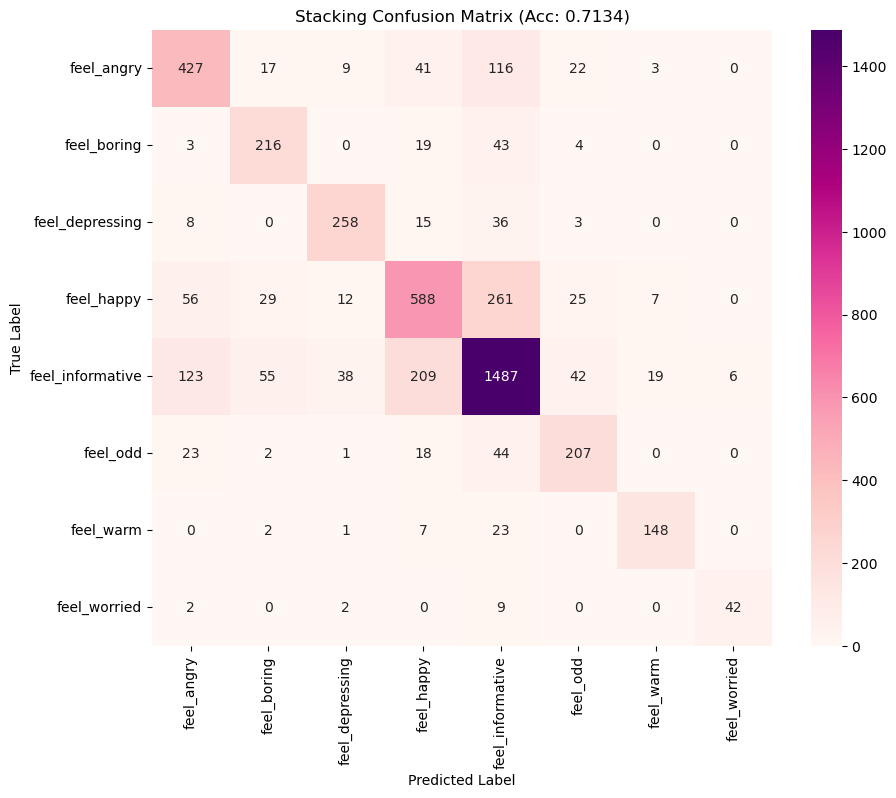

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import gc
from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, LabelBinarizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# 模型庫
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import StackingClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

if __name__ == '__main__':
    main_start = time.time()
    print("🚀 [步驟二] Stacking 混合訓練 (七大模型合體)...")

    # --- A. 讀取 ---
    try:
        df = pd.read_csv('Processed_Data.csv')
        df['text_segmented'] = df['text_segmented'].fillna('')
        print(f"✅ 資料載入成功: {len(df)} 筆")
    except:
        print("❌ 找不到 Processed_Data.csv")
        exit()

    X_text = df['text_segmented'].values
    y_raw = df['Column1'].values
    
    # 標籤編碼
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_raw)
    class_names = le.classes_
    
    del df
    gc.collect()

    # --- B. 特徵工程 ---
    print("🔄 TF-IDF 轉換 (Max 5000, float32)...")
    # 使用 float32 並限制特徵數，這是 Stacking 不爆記憶體的關鍵
    vectorizer = TfidfVectorizer(
        max_features=5000, 
        ngram_range=(1, 2), 
        min_df=5, 
        sublinear_tf=True,
        dtype=np.float32
    )
    X_tfidf = vectorizer.fit_transform(X_text)

    # --- C. 切分 ---
    print("✂️ 10-Fold 切分...")
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    train_idx, test_idx = next(kf.split(X_tfidf))
    
    X_train = X_tfidf[train_idx]
    X_test = X_tfidf[test_idx]
    y_train = y_encoded[train_idx]
    y_test = y_encoded[test_idx]
    
    X_train.sort_indices()
    X_test.sort_indices()
    
    # --- D. SMOTE 平衡 (可選) ---
    print("⚖️ 執行 SMOTE 過取樣...")
    try:
        smote = SMOTE(random_state=42)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
        print(f"   -> 訓練集擴增至: {X_train_res.shape[0]} 筆")
    except:
        print("   ⚠️ SMOTE 失敗，改用原始資料")
        X_train_res, y_train_res = X_train, y_train

    # --- E. 定義 Stacking 架構 ---
    print("WZ️ 定義模型組合...")
    
    # 基底模型 (Level 0)
    estimators = [
        ('nb', MultinomialNB()),
        ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1, random_state=42)),
        ('svm', CalibratedClassifierCV(LinearSVC(dual=False, class_weight='balanced', random_state=42))),
        # KNN 記憶體保護：單核
        ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=1)),
        # 樹模型記憶體保護：6核 + hist
        ('xgb', XGBClassifier(n_estimators=100, eval_metric='mlogloss', n_jobs=6, tree_method='hist', random_state=42)),
        ('lgbm', LGBMClassifier(n_estimators=100, class_weight='balanced', n_jobs=6, verbose=-1, random_state=42))
    ]
    
    # 堆疊分類器 (Level 1)
    # final_estimator 使用邏輯迴歸來做最終決策
    # n_jobs=1: 這是為了記憶體安全，強制一次只訓練一個基底模型
    clf = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000),
        n_jobs=1, 
        cv=5,
        verbose=1
    )

    # --- F. 訓練 ---
    print("🏋️ 開始訓練 Stacking 模型 (這會花一點時間，請稍候)...")
    
    # 針對 KNN 的特別處理：如果資料量過大，Stacking 裡的 KNN 必定會爆
    # 所以我們這裡做一個取捨：如果資料量 > 2萬，我們把 KNN 從 Stacking 中移除
    if X_train_res.shape[0] > 20000:
        print("   ⚠️ 訓練資料量大，為防崩潰，暫時移除 KNN...")
        estimators_safe = [e for e in estimators if e[0] != 'knn']
        clf.estimators = estimators_safe
    
    clf.fit(X_train_res, y_train_res)
    print(f"✅ 訓練完成！耗時: {time.time() - main_start:.1f} 秒")

    # --- G. 評估 ---
    print("📊 評估結果...")
    y_pred = clf.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"\n🏆 Stacking Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    # 繪圖
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Stacking Confusion Matrix (Acc: {acc:.4f})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()